In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

In [3]:
SOURCE_A_URLS = [
    "https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html",
    "https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html",
    "https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html",
    "https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html",
    "https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html",
    "https://techncruncher.blogspot.com/2022/07/top-10-ai-marketing-tools-you-should-use.html",
    "https://techncruncher.blogspot.com/2022/01/top-9-free-ai-tools-that-make-your-life.html",
    "https://techncruncher.blogspot.com/2022/01/7-free-websites-every-content-creator.html",
    "https://techncruncher.blogspot.com/2025/12/how-i-get-free-traffic-from-chatgpt-in.html",
    "https://techncruncher.blogspot.com/2025/11/what-is-blockchain-everything-you-need.html",
]

In [4]:
SOURCE_B_URLS = [
    "https://en.wikipedia.org/wiki/ChatGPT",
    "https://en.wikipedia.org/wiki/Artificial_intelligence",
    "https://en.wikipedia.org/wiki/Machine_learning",
    "https://en.wikipedia.org/wiki/Deep_learning",
    "https://en.wikipedia.org/wiki/Natural_language_processing",
    "https://en.wikipedia.org/wiki/Computer_vision",
    "https://en.wikipedia.org/wiki/Neural_network",
    "https://en.wikipedia.org/wiki/Large_language_model",
    "https://en.wikipedia.org/wiki/OpenAI",
    "https://en.wikipedia.org/wiki/TensorFlow",
]

In [5]:
def scrape_blogspot(url):
    """Scrape one techncruncher.blogspot.com article."""
    res = requests.get(url, headers=headers, timeout=10)
    res.raise_for_status()
    soup = BeautifulSoup(res.content, "lxml")

    title = soup.find("h3", class_="post-title")
    title = title.get_text(strip=True) if title else soup.title.get_text(strip=True)

    content_div = soup.find("div", class_="post-body entry-content")
    if not content_div:
        return None
    text = " ".join(p.get_text(strip=True) for p in content_div.find_all("p"))
    return title, text


def scrape_wikipedia(url):
    """Scrape one Wikipedia article."""
    res = requests.get(url, headers=headers, timeout=10)
    res.raise_for_status()
    soup = BeautifulSoup(res.content, "lxml")

    title = soup.find("h1", id="firstHeading")
    title = title.get_text(strip=True) if title else soup.title.get_text(strip=True)

    content_div = soup.find("div", id="mw-content-text")
    if not content_div:
        return None
    text = " ".join(p.get_text(strip=True) for p in content_div.find_all("p"))
    return title, text

In [6]:
def scrape_source(name, urls, scraper_fn):
    """Scrape a list of URLs with the given scraper function, label with source name."""
    rows = []
    for url in urls:
        try:
            result = scraper_fn(url)
            if result is None:
                print(f"[SKIP] No content block found: {url}")
                continue
            title, text = result
            if len(text) > 100:
                rows.append({"source": name, "url": url, "title": title, "text": text})
            else:
                print(f"[SKIP] Too short: {url}")
            time.sleep(1)
        except Exception as e:
            print(f"[ERROR] {url} -> {e}")
    return pd.DataFrame(rows)

In [7]:
corpus_a = scrape_source("techncruncher", SOURCE_A_URLS, scrape_blogspot)
corpus_b = scrape_source("wikipedia", SOURCE_B_URLS, scrape_wikipedia)

corpus = pd.concat([corpus_a, corpus_b], ignore_index=True)
corpus.to_csv("two_source_corpus.csv", index=False)
print(f"\nScraped {len(corpus_a)} from techncruncher, {len(corpus_b)} from wikipedia.")
print(f"Total: {len(corpus)} articles saved to two_source_corpus.csv")

[SKIP] Too short: https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html
[ERROR] https://techncruncher.blogspot.com/2025/11/what-is-blockchain-everything-you-need.html -> 404 Client Error: Not Found for url: https://techncruncher.blogspot.com/2025/11/what-is-blockchain-everything-you-need.html

Scraped 8 from techncruncher, 10 from wikipedia.
Total: 18 articles saved to two_source_corpus.csv


In [9]:
import spacy
from textblob import TextBlob

nlp = spacy.load("en_core_web_sm")
print("spaCy model loaded.")

spaCy model loaded.


In [10]:
def extract_all_features(text):
    """spaCy linguistic features + TextBlob sentiment, combined."""
    doc = nlp(text)
    sentences = list(doc.sents)
    blob = TextBlob(text)
    return pd.Series({
        'num_tokens':          len(doc),
        'num_sentences':       len(sentences),
        'num_entities':        len(doc.ents),
        'num_nouns':           len([t for t in doc if t.pos_ == 'NOUN']),
        'noun_density':        len([t for t in doc if t.pos_ == 'NOUN']) / len(doc) if len(doc) else 0,
        'sentiment_polarity':  blob.sentiment.polarity,
    })

features = corpus['text'].apply(extract_all_features)
corpus = pd.concat([corpus, features], axis=1)

print("Features extracted for all articles.")
corpus[['source', 'title', 'num_tokens', 'noun_density', 'sentiment_polarity']]

Features extracted for all articles.


,source,title,num_tokens,noun_density,sentiment_polarity
0,techncruncher,Top 10 AI Tools That Will Transform Your Conte...,1188.0,0.270202,0.229493
1,techncruncher,"LimeWire AI Studio Review 2023: Details, Prici...",1723.0,0.243761,0.219387
2,techncruncher,Top 10 AI Tools in 2023 That Will Make Your Li...,1480.0,0.223649,0.197417
3,techncruncher,Top 10 AI Content Generator & Writer Tools in ...,1319.0,0.205459,0.214853
4,techncruncher,TOP 11 AI MARKETING TOOLS YOU SHOULD USE (Upda...,1112.0,0.249101,0.123826
5,techncruncher,Top 9 Free AI Tools That Make Your Life Easier,657.0,0.213090,0.275093
6,techncruncher,7 Free Websites Every Content Creator Needs to...,358.0,0.175978,0.249776
7,techncruncher,How I Get Free Traffic from ChatGPT in 2025 (A...,9006.0,0.245392,0.142988
8,wikipedia,ChatGPT,5529.0,0.218484,0.075622
9,wikipedia,Artificial intelligence,13523.0,0.231014,0.073519


Mean values by source:

          source  sentiment_polarity  noun_density
0  techncruncher            0.206604      0.228329
1      wikipedia            0.064297      0.249387


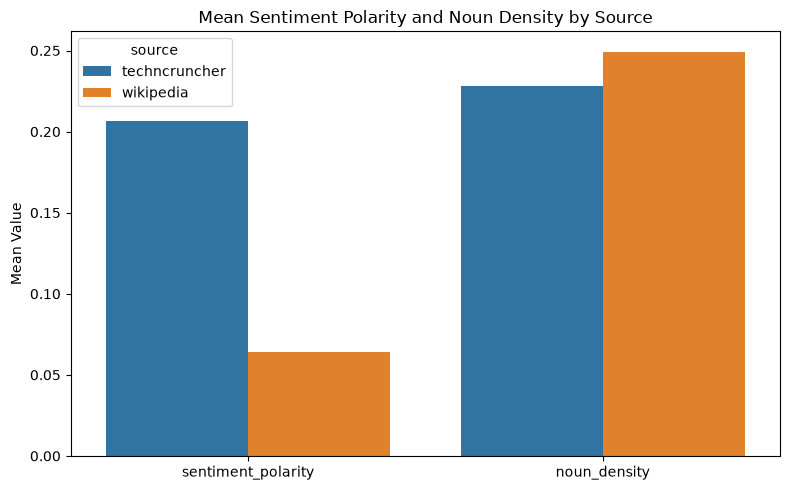

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison = corpus.groupby('source')[['sentiment_polarity', 'noun_density']].mean().reset_index()
print("Mean values by source:\n")
print(comparison)

comparison_melted = comparison.melt(id_vars='source', var_name='metric', value_name='mean_value')

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_melted, x='metric', y='mean_value', hue='source')
plt.title('Mean Sentiment Polarity and Noun Density by Source')
plt.ylabel('Mean Value')
plt.xlabel('')
plt.tight_layout()
plt.show()

## Home Assignment: Findings

18 articles were scraped from two sources (8 from techncruncher.blogspot.com, 10 from Wikipedia — 
2 techncruncher URLs failed: one too short, one returned a 404 error).

**Sentiment polarity:** techncruncher articles averaged 0.207 (mildly positive), while Wikipedia 
articles averaged 0.064 (nearly neutral). This makes sense: techncruncher publishes promotional 
"top 10 tools" blog posts, while Wikipedia aims for a neutral, encyclopedic tone.

**Noun density:** techncruncher averaged 0.228 and Wikipedia averaged 0.249 — a smaller difference, 
suggesting both styles use nouns at a broadly similar rate.

**Is this difference meaningful?** With only 8-10 articles per source, this sample is far too small 
to draw statistically confident conclusions. A single unusually promotional or unusually technical 
article could shift the average noticeably. The sentiment difference is large and matches an 
intuitive expectation (blogs vs. encyclopedia), so it is plausible, but it should be confirmed with 
a much larger sample and a formal statistical test (e.g. a t-test) before being treated as a firm 
finding rather than a suggestive pattern.